# Fine-tuning OWL-ViT

This notebook fine-tunes OWL-ViT (Open-Vocabulary Object Detection with Vision Transformers) to detect bounding boxes of UI elements on phone screens.

In [1]:
# Import required libraries
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

c:\Users\micha\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.7.0+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2060


## 1. Load and Prepare Dataset

In [2]:
# Load dataset
csv_path = "../data/screen_annotation/extracted_annotations.csv"
image_folder = "../data/screen_annotation/images"

df = pd.read_csv(csv_path)
print(f"Total samples: {len(df)}")
print(f"\nFirst few rows:")
print(df.head())

# Check data distribution
print(f"\nUnique screens: {df['screen_id'].nunique()}")
print(f"\nType distribution:")
print(df['type'].value_counts())

# df = df[df['type'].isin(['IMAGE', 'PICTOGRAM'])]
df = df.sample(n=min(10000, len(df)), random_state=42).reset_index(drop=True)
print(f"\nUsing {len(df)} samples for training")

Total samples: 371146

First few rows:
   screen_id   type           text   x1   y1   x2   y2
0      39382   TEXT  Currency code   79   78  923  111
1      39382  LABEL            USD  205  131  305  163
2      39382  LABEL            UYU  202  198  306  229
3      39382  LABEL            UZS  203  264  303  294
4      39382  LABEL            VEB  206  330  303  360

Unique screens: 22073

Type distribution:
type
TEXT          160062
PICTOGRAM     141144
BUTTON         32276
IMAGE          21762
LABEL          15637
TEXT_INPUT       265
Name: count, dtype: int64

Using 10000 samples for training


In [3]:
# Split dataset: 70% train, 10% val, 20% test
train_size = int(0.7 * len(df))
val_size = int(0.1 * len(df))

train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]

print(f"Train: {len(train_df)} samples")
print(f"Val:   {len(val_df)} samples")
print(f"Test:  {len(test_df)} samples")

Train: 7000 samples
Val:   1000 samples
Test:  2000 samples


## 2. Dataset Class and DataLoader

In [4]:
class UIElementDataset(Dataset):
    """Dataset for UI element detection with OWL-ViT"""
    
    def __init__(self, df, image_folder, processor):
        self.df = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_folder, f"{row['screen_id']}.jpg")
        image = Image.open(image_path).convert("RGB")
        
        # Text query for this UI element
        text = str(row["text"])
        
        # Get original image dimensions
        orig_w, orig_h = image.size
        
        # Dataset coordinates are normalized 0-999, convert to pixel coordinates
        x1 = (float(row["x1"]) / 999.0) * orig_w
        y1 = (float(row["y1"]) / 999.0) * orig_h
        x2 = (float(row["x2"]) / 999.0) * orig_w
        y2 = (float(row["y2"]) / 999.0) * orig_h
        
        # OWL-ViT processor resizes to 768x768
        processed_size = 768
        scale_x = processed_size / orig_w
        scale_y = processed_size / orig_h
        
        # Scale box coordinates to processed space
        x1_proc = x1 * scale_x
        y1_proc = y1 * scale_y
        x2_proc = x2 * scale_x
        y2_proc = y2 * scale_y
        
        # Convert to center + size format (OWL-ViT uses this)
        cx = (x1_proc + x2_proc) / 2
        cy = (y1_proc + y2_proc) / 2
        box_w = x2_proc - x1_proc
        box_h = y2_proc - y1_proc
        
        # Normalize to [0, 1] relative to processed 768x768 space
        target_boxes = [[
            cx / processed_size,
            cy / processed_size,
            box_w / processed_size,
            box_h / processed_size
        ]]
        
        return {
            "image": image,
            "text": [text],
            "target_boxes": torch.tensor(target_boxes, dtype=torch.float32),
            "screen_id": row["screen_id"]
        }


def collate_fn(batch, processor):
    """Collate function for DataLoader"""
    images = [item['image'] for item in batch]
    texts = [item['text'][0] for item in batch]
    target_boxes = torch.stack([item['target_boxes'] for item in batch])
    
    # Process images and text
    inputs = processor(
        text=texts, 
        images=images, 
        return_tensors="pt", 
        padding=True,
        truncation=True,
        max_length=16
    )
    
    return {
        **inputs,
        "target_boxes": target_boxes,
        "screen_ids": [item['screen_id'] for item in batch]
    }

## 3. Loss Functions

In [5]:
class FocalLoss(nn.Module):
    """
    Focal Loss for classification (from OWL-ViT/DETR)
    - Downweights easy examples (confident correct predictions)
    - Focuses training on hard negatives
    - Essential for handling class imbalance (many background patches)
    """
    def __init__(self, alpha=0.3, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # Weight for positive class
        self.gamma = gamma
    
    def forward(self, logits, targets):
        """
        Args:
            logits: raw logits (before sigmoid)
            targets: binary labels (0 or 1)
        """
        probs = torch.sigmoid(logits)
        ce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        
        # Focal loss modulation
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Alpha balancing
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        loss = alpha_t * focal_weight * ce_loss
        return loss.mean()


def compute_iou(pred_boxes, target_boxes, eps=1e-7):
    """Compute IoU for center+size format boxes (for metrics)"""
    pred_cx, pred_cy, pred_w, pred_h = pred_boxes.unbind(-1)
    target_cx, target_cy, target_w, target_h = target_boxes.unbind(-1)
    
    pred_x1 = pred_cx - pred_w / 2
    pred_y1 = pred_cy - pred_h / 2
    pred_x2 = pred_cx + pred_w / 2
    pred_y2 = pred_cy + pred_h / 2
    
    target_x1 = target_cx - target_w / 2
    target_y1 = target_cy - target_h / 2
    target_x2 = target_cx + target_w / 2
    target_y2 = target_cy + target_h / 2
    
    x1_inter = torch.max(pred_x1, target_x1)
    y1_inter = torch.max(pred_y1, target_y1)
    x2_inter = torch.min(pred_x2, target_x2)
    y2_inter = torch.min(pred_y2, target_y2)
    
    inter_area = (
        torch.clamp(x2_inter - x1_inter, min=0) * 
        torch.clamp(y2_inter - y1_inter, min=0)
    )
    
    pred_area = pred_w * pred_h
    target_area = target_w * target_h
    union_area = pred_area + target_area - inter_area + eps
    
    iou = inter_area / union_area
    return iou

In [6]:
def assign_patches_hungarian(pred_boxes, target_box):
    """
    Hungarian matching (used in OWL-ViT):
    - Assigns exactly ONE patch to the ground truth box
    - Uses IoU as the matching criterion
    
    Args:
        pred_boxes: predicted boxes
        target_box: ground truth box
    
    Returns:
        matched_idx: index of matched patch
        labels: binary labels (1 for matched, 0 for others)
    """
    num_patches = pred_boxes.shape[0]
    target_boxes_expanded = target_box.unsqueeze(0).expand(num_patches, -1)
    
    # Compute IoU for all patches
    ious = compute_iou(pred_boxes, target_boxes_expanded)
    
    # For single object case, pick patch with highest IoU
    matched_idx = ious.argmax().item()
    
    # Create binary labels: 1 for matched patch, 0 for all others
    labels = torch.zeros(num_patches, device=pred_boxes.device)
    labels[matched_idx] = 1.0
    
    return matched_idx, labels

## 4. Load Model and Create DataLoaders

In [7]:
# Load OWL-ViT model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "google/owlvit-base-patch32"
processor = OwlViTProcessor.from_pretrained(model_name)
model = OwlViTForObjectDetection.from_pretrained(model_name).to(device)

print(f"Loaded {model_name}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Using device: cuda
Loaded google/owlvit-base-patch32
Total parameters: 153.2M
Loaded google/owlvit-base-patch32
Total parameters: 153.2M


In [8]:
# Create datasets
train_dataset = UIElementDataset(train_df, image_folder, processor)
val_dataset = UIElementDataset(val_df, image_folder, processor)
test_dataset = UIElementDataset(test_df, image_folder, processor)

# Create dataloaders
batch_size = 8
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True, 
    collate_fn=lambda b: collate_fn(b, processor),
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=lambda b: collate_fn(b, processor),
    num_workers=0
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=lambda b: collate_fn(b, processor),
    num_workers=0
)

print(f"DataLoaders created (batch_size={batch_size})")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

DataLoaders created (batch_size=8)
Train batches: 875
Val batches:   125
Test batches:  250


## 5. Training Setup

In [9]:
# Initialize loss functions
cls_criterion = FocalLoss(alpha=0.3, gamma=2.0)

# Loss weights
lambda_cls = 1.0   # Classification weight
lambda_smooth_l1 = 1.0  # Box coordinate loss weight

print(f"Loss configuration:")
print(f"  lambda_cls      = {lambda_cls}")
print(f"  lambda_smooth_l1 = {lambda_smooth_l1}")

Loss configuration:
  lambda_cls      = 1.0
  lambda_smooth_l1 = 1.0


In [10]:
# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze prediction heads
for param in model.class_head.parameters():
    param.requires_grad = True
for param in model.box_head.parameters():
    param.requires_grad = True

# Unfreeze last N layers of vision encoder
vision_layers = model.owlvit.vision_model.encoder.layers
num_unfreeze_vision = 6
for layer in vision_layers[-num_unfreeze_vision:]:
    for param in layer.parameters():
        param.requires_grad = True

# Unfreeze last N layers of text encoder  
text_layers = model.owlvit.text_model.encoder.layers
num_unfreeze_text = 2
for layer in text_layers[-num_unfreeze_text:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Unfroze last {num_unfreeze_vision} vision & {num_unfreeze_text} text layers")
print(f"Trainable: {trainable / 1e6:.1f}M / {total / 1e6:.1f}M ({100 * trainable / total:.1f}%)")

Unfroze last 6 vision & 2 text layers
Trainable: 50.4M / 153.2M (32.9%)


In [11]:
# Create parameter groups with different learning rates
head_params = list(model.class_head.parameters()) + list(model.box_head.parameters())
vision_params = []
for layer in vision_layers[-num_unfreeze_vision:]:
    vision_params.extend(list(layer.parameters()))
text_params = []
for layer in text_layers[-num_unfreeze_text:]:
    text_params.extend(list(layer.parameters()))

# Optimizer with different LRs for different parts
optimizer = torch.optim.AdamW([
    {'params': head_params, 'lr': 3e-4, 'name': 'heads'},
    {'params': vision_params, 'lr': 8e-6, 'name': 'vision'},
    {'params': text_params, 'lr': 2e-6, 'name': 'text'}
], betas=(0.9, 0.98), weight_decay=0.01)

## 6. Training Loop

In [12]:
# Training hyperparameters
num_epochs = 1
best_val_iou = 0.0
patience = 5
patience_counter = 0

# Storage for metrics
epoch_train_losses, epoch_val_losses = [], []
epoch_train_ious, epoch_val_ious = [], []
epoch_train_cls, epoch_train_smooth_l1 = [], []

# Scheduler
total_steps = num_epochs * len(train_loader)
warmup_steps = int(0.05 * total_steps)

from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_steps)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps, eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])

global_step = 0

In [13]:
# Visualization helper function
def visualize_batch_predictions(images, texts, pred_boxes_batch, pred_logits_batch, 
                                target_boxes_batch, batch_num, epoch_num, num_samples=4):
    """Visualize predictions during training"""
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 5))
    if num_samples == 1:
        axes = [axes]
    
    for idx in range(num_samples):
        # Get data for this image
        img = images[idx]
        text = texts[idx]
        pred_boxes = pred_boxes_batch[idx]
        pred_logits = pred_logits_batch[idx]
        target_box = target_boxes_batch[idx]
        
        # Get top 3 predictions
        top3_indices = torch.topk(pred_logits, k=3).indices
        top3_boxes = pred_boxes[top3_indices]
        top3_scores = torch.sigmoid(pred_logits[top3_indices])
        
        # Convert to numpy for plotting
        img_array = np.array(img)
        h, w = img_array.shape[:2]
        
        ax = axes[idx]
        ax.imshow(img_array)
        
        # Plot ground truth (green)
        gt_cx, gt_cy, gt_w, gt_h = target_box.cpu()
        gt_x1 = (gt_cx - gt_w / 2) * w
        gt_y1 = (gt_cy - gt_h / 2) * h
        gt_box_w = gt_w * w
        gt_box_h = gt_h * h
        
        rect_gt = patches.Rectangle(
            (gt_x1, gt_y1), gt_box_w, gt_box_h,
            linewidth=3, edgecolor='lime', facecolor='none',
            label='Ground Truth'
        )
        ax.add_patch(rect_gt)
        
        # Plot top 3 predictions (red, orange, yellow)
        colors = ['red', 'orange', 'gold']
        linestyles = ['--', '-.', ':']
        for i, (box, score) in enumerate(zip(top3_boxes, top3_scores)):
            pred_cx, pred_cy, pred_w, pred_h = box.cpu()
            pred_x1 = (pred_cx - pred_w / 2) * w
            pred_y1 = (pred_cy - pred_h / 2) * h
            pred_box_w = pred_w * w
            pred_box_h = pred_h * h
            
            rect_pred = patches.Rectangle(
                (pred_x1, pred_y1), pred_box_w, pred_box_h,
                linewidth=2, edgecolor=colors[i], facecolor='none',
                linestyle=linestyles[i], 
                label=f'#{i+1}: {score:.3f}'
            )
            ax.add_patch(rect_pred)
        
        # Truncate long text
        display_text = text if len(text) <= 25 else text[:22] + "..."
        ax.set_title(f'"{display_text}"', fontsize=10, fontweight='bold')
        ax.axis('off')
        ax.legend(loc='upper right', fontsize=7)
    
    plt.suptitle(f'Epoch {epoch_num+1}, Batch {batch_num+1} - Top 3 Predictions', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../results/epoch_{epoch_num+1}_batch_{batch_num+1}.png', dpi=150, bbox_inches='tight')
    plt.close()

In [14]:
for epoch in range(num_epochs):
    model.train()
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\n{'='*70}")
    print(f"Epoch [{epoch+1}/{num_epochs}] - LR: {current_lr:.2e}")
    print(f"{'='*70}")
    
    train_losses, train_ious = [], []
    train_cls_losses, train_smooth_l1_losses = [], []
    
    for i, batch in enumerate(train_loader):
        print("  Processing batch {}/{}".format(i+1, len(train_loader)), end='\r')

        # Move batch to device
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        target_boxes = batch['target_boxes'].to(device)
        
        # Forward pass
        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        pred_boxes = outputs.pred_boxes
        
        batch_size = logits.shape[0]
        
        # Compute losses per image
        cls_loss_total = 0
        smooth_l1_loss_total = 0
        best_pred_boxes = []
        
        for b in range(batch_size):
            image_logits = logits[b, :, 0]
            image_pred_boxes = pred_boxes[b, :, :]
            target_box = target_boxes[b, 0, :]
            
            # Hungarian matching: assign one patch to ground truth
            matched_idx, cls_targets = assign_patches_hungarian(
                image_pred_boxes, target_box
            )
            
            # Classification loss
            cls_loss = cls_criterion(image_logits, cls_targets)
            cls_loss_total += cls_loss
            
            # Box regression loss
            matched_pred_box = image_pred_boxes[matched_idx:matched_idx+1, :]
            target_box_expanded = target_box.unsqueeze(0)
            
            smooth_l1_loss = nn.functional.smooth_l1_loss(matched_pred_box, target_box_expanded, beta=1.0)
            smooth_l1_loss_total += smooth_l1_loss
            
            # For metrics: get best prediction
            best_patch_idx = image_logits.argmax()
            best_pred_boxes.append(image_pred_boxes[best_patch_idx, :])
        
        # Average losses
        cls_loss_total = cls_loss_total / batch_size
        smooth_l1_loss_total = smooth_l1_loss_total / batch_size
        
        # Combined loss
        loss = (lambda_cls * cls_loss_total + 
                lambda_smooth_l1 * smooth_l1_loss_total)
        
        # Compute IoU for metrics
        pred_boxes_stacked = torch.stack(best_pred_boxes)
        target_boxes_squeezed = target_boxes.squeeze(1)
        
        with torch.no_grad():
            iou = compute_iou(pred_boxes_stacked, target_boxes_squeezed)
            train_ious.append(iou.mean().item())
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        scheduler.step()
        
        global_step += 1
        
        # Store losses
        train_losses.append(loss.item())
        train_cls_losses.append(cls_loss_total.item())
        train_smooth_l1_losses.append(smooth_l1_loss_total.item())
        
        # Print progress
        num_batches_to_display = 10

        if i % num_batches_to_display == 0 or i == len(train_loader) - 1:
            print(f"  Batch [{i+1}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f} | "
                  f"Cls: {cls_loss_total.item():.4f} | "
                  f"SmoothL1: {smooth_l1_loss_total.item():.4f} | "
                  f"IoU: {iou.mean().item():.4f}")
        
        # Visualize predictions every N batches
        if i % num_batches_to_display == 0:
            with torch.no_grad():
                # CLIP normalization parameters for denormalization
                mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1).to(device)
                std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1).to(device)
                
                # Denormalize pixel_values to get natural colors
                denorm_pixel_values = pixel_values * std + mean
                denorm_pixel_values = torch.clamp(denorm_pixel_values, 0, 1)
                
                # Convert denormalized tensors to PIL images
                batch_images = [
                    Image.fromarray((denorm_pixel_values[b].cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8))
                    for b in range(min(4, batch_size))
                ]
                batch_texts = [processor.tokenizer.decode(
                    input_ids[b], skip_special_tokens=True
                ) for b in range(min(4, batch_size))]
                
                visualize_batch_predictions(
                    images=batch_images,
                    texts=batch_texts,
                    pred_boxes_batch=pred_boxes[:4].detach(),
                    pred_logits_batch=logits[:4, :, 0].detach(),
                    target_boxes_batch=target_boxes[:4, 0].detach(),
                    batch_num=i,
                    epoch_num=epoch,
                    num_samples=min(4, batch_size)
                )
            print()
    
    # Epoch training metrics
    avg_train_loss = sum(train_losses) / len(train_losses)
    avg_train_iou = sum(train_ious) / len(train_ious)
    avg_train_cls = sum(train_cls_losses) / len(train_cls_losses)
    avg_train_smooth_l1 = sum(train_smooth_l1_losses) / len(train_smooth_l1_losses)
    
    print(f"\n  Train Summary:")
    print(f"    Total: {avg_train_loss:.4f} | "
          f"Cls: {avg_train_cls:.4f} | "
          f"SmoothL1: {avg_train_smooth_l1:.4f} | "
          f"IoU: {avg_train_iou:.4f}")
    
    # Validation
    model.eval()
    val_losses, val_ious = [], []
    val_cls_losses, val_smooth_l1_losses = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            target_boxes = batch['target_boxes'].to(device)
            
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            logits = outputs.logits
            pred_boxes = outputs.pred_boxes
            batch_size = logits.shape[0]
            
            cls_loss_total = 0
            smooth_l1_loss_total = 0
            best_pred_boxes = []
            
            for b in range(batch_size):
                image_logits = logits[b, :, 0]
                image_pred_boxes = pred_boxes[b, :, :]
                target_box = target_boxes[b, 0, :]
                
                matched_idx, cls_targets = assign_patches_hungarian(
                    image_pred_boxes, target_box
                )
                
                cls_loss = cls_criterion(image_logits, cls_targets)
                cls_loss_total += cls_loss
                
                matched_pred_box = image_pred_boxes[matched_idx:matched_idx+1, :]
                target_box_expanded = target_box.unsqueeze(0)
                
                smooth_l1_loss = nn.functional.smooth_l1_loss(matched_pred_box, target_box_expanded, beta=1.0)
                smooth_l1_loss_total += smooth_l1_loss
                
                best_patch_idx = image_logits.argmax()
                best_pred_boxes.append(image_pred_boxes[best_patch_idx, :])
            
            cls_loss_total = cls_loss_total / batch_size
            smooth_l1_loss_total = smooth_l1_loss_total / batch_size
            
            loss = (lambda_cls * cls_loss_total + 
                    lambda_smooth_l1 * smooth_l1_loss_total)
            
            pred_boxes_stacked = torch.stack(best_pred_boxes)
            target_boxes_squeezed = target_boxes.squeeze(1)
            iou = compute_iou(pred_boxes_stacked, target_boxes_squeezed)
            
            val_losses.append(loss.item())
            val_cls_losses.append(cls_loss_total.item())
            val_smooth_l1_losses.append(smooth_l1_loss_total.item())
            val_ious.append(iou.mean().item())
    
    mean_val_loss = sum(val_losses) / len(val_losses)
    mean_val_iou = sum(val_ious) / len(val_ious)
    mean_val_cls = sum(val_cls_losses) / len(val_cls_losses)
    mean_val_smooth_l1 = sum(val_smooth_l1_losses) / len(val_smooth_l1_losses)
    
    print(f"  Val   Summary:")
    print(f"    Total: {mean_val_loss:.4f} | "
          f"Cls: {mean_val_cls:.4f} | "
          f"SmoothL1: {mean_val_smooth_l1:.4f} | "
          f"IoU: {mean_val_iou:.4f}")
    
    # Store epoch metrics
    epoch_train_losses.append(avg_train_loss)
    epoch_val_losses.append(mean_val_loss)
    epoch_train_ious.append(avg_train_iou)
    epoch_val_ious.append(mean_val_iou)
    epoch_train_cls.append(avg_train_cls)
    epoch_train_smooth_l1.append(avg_train_smooth_l1)
    
    # Save best model
    if mean_val_iou > best_val_iou:
        best_val_iou = mean_val_iou
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': mean_val_loss,
            'val_iou': mean_val_iou,
        }, '../src/best_bounding_box_model.pth')
        print(f"\n  Best model saved! (Val IoU: {best_val_iou:.4f})")
    else:
        patience_counter += 1
        print(f"\n  No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"  Early stopping triggered!")
            break



Epoch [1/1] - LR: 3.00e-05
  Batch [1/875] Loss: 0.0042 | Cls: 0.0039 | SmoothL1: 0.0003 | IoU: 0.0037
  Batch [1/875] Loss: 0.0042 | Cls: 0.0039 | SmoothL1: 0.0003 | IoU: 0.0037


  Batch [11/875] Loss: 0.0022 | Cls: 0.0020 | SmoothL1: 0.0002 | IoU: 0.1386
  Batch [11/875] Loss: 0.0022 | Cls: 0.0020 | SmoothL1: 0.0002 | IoU: 0.1386


  Batch [21/875] Loss: 0.0023 | Cls: 0.0020 | SmoothL1: 0.0004 | IoU: 0.1463
  Batch [21/875] Loss: 0.0023 | Cls: 0.0020 | SmoothL1: 0.0004 | IoU: 0.1463


  Batch [31/875] Loss: 0.0031 | Cls: 0.0018 | SmoothL1: 0.0013 | IoU: 0.0085
  Batch [31/875] Loss: 0.0031 | Cls: 0.0018 | SmoothL1: 0.0013 | IoU: 0.0085


  Batch [41/875] Loss: 0.0018 | Cls: 0.0016 | SmoothL1: 0.0003 | IoU: 0.1143
  Batch [41/875] Loss: 0.0018 | Cls: 0.0016 | SmoothL1: 0.0003 | IoU: 0.1143


  Batch [51/875] Loss: 0.0049 | Cls: 0.0016 | SmoothL1: 0.0033 | IoU: 0.2964
  Batch [51/875] Loss: 0.0049 | Cls: 0.0016 | SmoothL1: 0.0033 | IoU: 0.2964


  Batch [61/875] Loss: 0.0021 | Cls: 0

C:\Users\micha\AppData\Local\Temp\ipykernel_29276\2454256642.py:70: UserWarning: Glyph 12520 (\N{KATAKANA LETTER YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\micha\AppData\Local\Temp\ipykernel_29276\2454256642.py:71: UserWarning: Glyph 12520 (\N{KATAKANA LETTER YO}) missing from font(s) DejaVu Sans.
  plt.savefig(f'../results/epoch_{epoch_num+1}_batch_{batch_num+1}.png', dpi=150, bbox_inches='tight')



  Batch [781/875] Loss: 0.0018 | Cls: 0.0010 | SmoothL1: 0.0008 | IoU: 0.1727
  Batch [781/875] Loss: 0.0018 | Cls: 0.0010 | SmoothL1: 0.0008 | IoU: 0.1727


  Batch [791/875] Loss: 0.0015 | Cls: 0.0010 | SmoothL1: 0.0004 | IoU: 0.1233
  Batch [791/875] Loss: 0.0015 | Cls: 0.0010 | SmoothL1: 0.0004 | IoU: 0.1233


  Batch [801/875] Loss: 0.0011 | Cls: 0.0010 | SmoothL1: 0.0001 | IoU: 0.0000
  Batch [801/875] Loss: 0.0011 | Cls: 0.0010 | SmoothL1: 0.0001 | IoU: 0.0000


  Batch [811/875] Loss: 0.0017 | Cls: 0.0010 | SmoothL1: 0.0007 | IoU: 0.3004
  Batch [811/875] Loss: 0.0017 | Cls: 0.0010 | SmoothL1: 0.0007 | IoU: 0.3004


  Batch [821/875] Loss: 0.0014 | Cls: 0.0008 | SmoothL1: 0.0006 | IoU: 0.2818
  Batch [821/875] Loss: 0.0014 | Cls: 0.0008 | SmoothL1: 0.0006 | IoU: 0.2818


  Batch [831/875] Loss: 0.0037 | Cls: 0.0012 | SmoothL1: 0.0026 | IoU: 0.1623
  Batch [831/875] Loss: 0.0037 | Cls: 0.0012 | SmoothL1: 0.0026 | IoU: 0.1623


  Batch [841/875] Loss: 0.0010 | Cls: 0.0009 | Smoo

## 7. Test Evaluation

In [15]:
# Load best model
checkpoint = torch.load('../src/best_bounding_box_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation IoU: {checkpoint['val_iou']:.4f}")

# Evaluate on test set
model.eval()
test_losses, test_ious = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        target_boxes = batch['target_boxes'].to(device)
        
        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        pred_boxes = outputs.pred_boxes
        batch_size = logits.shape[0]
        
        cls_loss_total = 0
        smooth_l1_loss_total = 0
        best_pred_boxes = []
        
        for b in range(batch_size):
            image_logits = logits[b, :, 0]
            image_pred_boxes = pred_boxes[b, :, :]
            target_box = target_boxes[b, 0, :]
            
            matched_idx, cls_targets = assign_patches_hungarian(
                image_pred_boxes, target_box
            )
            
            cls_loss = cls_criterion(image_logits, cls_targets)
            cls_loss_total += cls_loss
            
            matched_pred_box = image_pred_boxes[matched_idx:matched_idx+1, :]
            target_box_expanded = target_box.unsqueeze(0)
            
            smooth_l1_loss = nn.functional.smooth_l1_loss(matched_pred_box, target_box_expanded, beta=1.0)
            smooth_l1_loss_total += smooth_l1_loss
            
            best_patch_idx = image_logits.argmax()
            best_pred_boxes.append(image_pred_boxes[best_patch_idx, :])
        
        cls_loss_total = cls_loss_total / batch_size
        smooth_l1_loss_total = smooth_l1_loss_total / batch_size
        
        loss = (lambda_cls * cls_loss_total + 
                lambda_smooth_l1 * smooth_l1_loss_total)
        
        pred_boxes_stacked = torch.stack(best_pred_boxes)
        target_boxes_squeezed = target_boxes.squeeze(1)
        iou = compute_iou(pred_boxes_stacked, target_boxes_squeezed)
        
        test_losses.append(loss.item())
        test_ious.extend(iou.cpu().tolist())

mean_test_loss = sum(test_losses) / len(test_losses)
mean_test_iou = sum(test_ious) / len(test_ious)
median_test_iou = sorted(test_ious)[len(test_ious)//2]

print(f"\n{'='*70}")
print(f"TEST RESULTS")
print(f"{'='*70}")
print(f"Test Loss: {mean_test_loss:.4f}")
print(f"Test IoU (mean):   {mean_test_iou:.4f}")
print(f"Test IoU (median): {median_test_iou:.4f}")
print(f"{'='*70}")

Loaded best model from epoch 1
Best validation IoU: 0.1935

TEST RESULTS
Test Loss: 0.0020
Test IoU (mean):   0.1910
Test IoU (median): 0.0000

TEST RESULTS
Test Loss: 0.0020
Test IoU (mean):   0.1910
Test IoU (median): 0.0000


## 8. Visualize Results

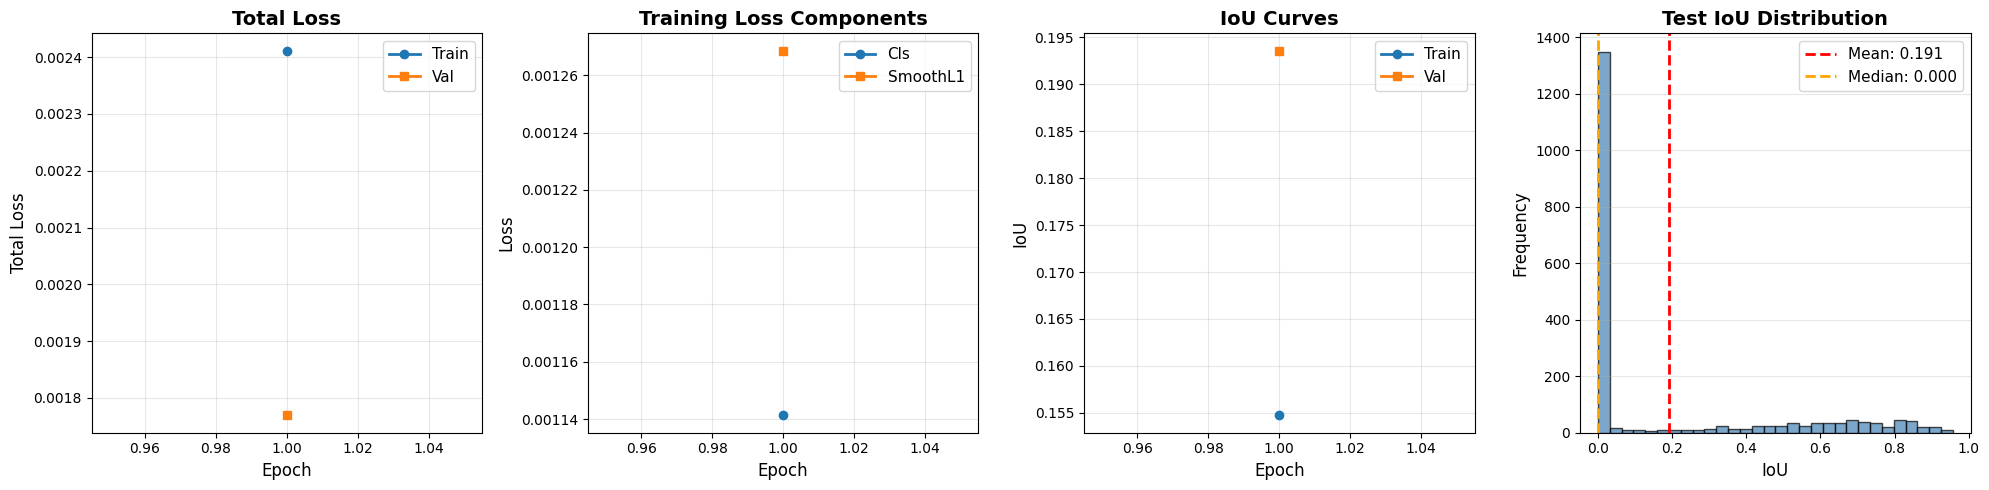


  Training curves saved to ../results/training_results.png


In [16]:
# Plot training curves
fig = plt.figure(figsize=(20, 5))

# Total loss
plt.subplot(1, 4, 1)
plt.plot(range(1, len(epoch_train_losses)+1), epoch_train_losses, 
         label='Train', marker='o', linewidth=2)
plt.plot(range(1, len(epoch_val_losses)+1), epoch_val_losses, 
         label='Val', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Total Loss', fontsize=12)
plt.title('Total Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Loss components
plt.subplot(1, 4, 2)
plt.plot(range(1, len(epoch_train_cls)+1), epoch_train_cls, 
         label='Cls', marker='o', linewidth=2)
plt.plot(range(1, len(epoch_train_smooth_l1)+1), epoch_train_smooth_l1, 
         label='SmoothL1', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Components', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# IoU curves
plt.subplot(1, 4, 3)
plt.plot(range(1, len(epoch_train_ious)+1), epoch_train_ious, 
         label='Train', marker='o', linewidth=2)
plt.plot(range(1, len(epoch_val_ious)+1), epoch_val_ious, 
         label='Val', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('IoU', fontsize=12)
plt.title('IoU Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Test IoU distribution
plt.subplot(1, 4, 4)
plt.hist(test_ious, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('IoU', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Test IoU Distribution', fontsize=14, fontweight='bold')
plt.axvline(mean_test_iou, color='r', linestyle='--', linewidth=2,
            label=f'Mean: {mean_test_iou:.3f}')
plt.axvline(median_test_iou, color='orange', linestyle='--', linewidth=2,
            label=f'Median: {median_test_iou:.3f}')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Training curves saved to ../results/training_results.png")

In [17]:
# Visualize sample predictions
def visualize_predictions(model, dataset, num_samples=8):
    """Visualize model predictions on sample images"""
    model.eval()
    
    # Get random samples
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    num_cols = 4
    num_rows = (num_samples + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            sample = dataset[sample_idx]
            image = sample['image']
            text_query = sample['text'][0]
            target_box = sample['target_boxes'][0]
            
            # Process single image
            inputs = processor(
                text=[text_query], 
                images=[image], 
                return_tensors="pt",
                truncation=True,
                max_length=16
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Get predictions
            outputs = model(**inputs)
            logits = outputs.logits[0, :, 0]
            pred_boxes_all = outputs.pred_boxes[0]
            
            # Get best prediction
            best_idx = logits.argmax()
            pred_box = pred_boxes_all[best_idx]
            score = torch.sigmoid(logits[best_idx]).item()
            
            # Move target_box to same device as pred_box
            target_box = target_box.to(pred_box.device)
            
            # Compute IoU
            iou = compute_iou(pred_box.unsqueeze(0), target_box.unsqueeze(0)).item()
            
            # Denormalize image
            img_array = np.array(image)
            h, w = img_array.shape[:2]
            
            # Convert boxes from normalized [0,1] to pixel coords
            # Target box
            target_cx, target_cy, target_w, target_h = target_box.cpu()
            target_x1 = (target_cx - target_w / 2) * w
            target_y1 = (target_cy - target_h / 2) * h
            target_box_w = target_w * w
            target_box_h = target_h * h
            
            # Predicted box
            pred_cx, pred_cy, pred_w, pred_h = pred_box.cpu()
            pred_x1 = (pred_cx - pred_w / 2) * w
            pred_y1 = (pred_cy - pred_h / 2) * h
            pred_box_w = pred_w * w
            pred_box_h = pred_h * h
            
            # Plot
            ax = axes[idx]
            ax.imshow(img_array)
            
            # Ground truth (green)
            rect_gt = patches.Rectangle(
                (target_x1, target_y1), target_box_w, target_box_h,
                linewidth=3, edgecolor='lime', facecolor='none',
                label='Ground Truth'
            )
            ax.add_patch(rect_gt)
            
            # Prediction (red)
            rect_pred = patches.Rectangle(
                (pred_x1, pred_y1), pred_box_w, pred_box_h,
                linewidth=3, edgecolor='red', facecolor='none',
                linestyle='--', label=f'Pred (score={score:.2f})'
            )
            ax.add_patch(rect_pred)
            
            # Truncate long text
            display_text = text_query if len(text_query) <= 30 else text_query[:27] + "..."
            
            ax.set_title(f'IoU: {iou:.3f}\n"{display_text}"', 
                        fontsize=10, fontweight='bold')
            ax.axis('off')
            ax.legend(loc='upper right', fontsize=8)
    
    # Hide unused subplots
    for idx in range(num_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('../results/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"Sample predictions saved to ../results/sample_predictions.png")

# Visualize test set predictions
visualize_predictions(model, test_dataset, num_samples=4)

Sample predictions saved to ../results/sample_predictions.png


## Summary

The model has been fine-tuned to detect UI element bounding boxes using:
- **Classification Loss**: Focal Loss to identify which image patch contains the target
- **Regression Loss**: Smooth L1 loss to refine bounding box coordinates
- **Hungarian Matching**: Assigns exactly one patch to each ground truth box

**Key Results:**
- Best model saved to `../src/best_bounding_box_model.pth`
- Training curves saved to `../results/training_results.png`
- Sample predictions saved to `../results/sample_predictions.png`